# **Algebra lineal** 📚

**Nombre**: Axel, alias JASM18

**Fecha de entrega**: 5 de Diciembre del 2025

# **Apuntes de clase** 📝

## **Introduccón al parcial 3** - 21 de Octubre del 2025

Los temas que se van a ver en esta libreta son:
1. **Métodos directos** (LU, eliminación Gaussiana, factorización de Cholesky)
2. **Métodos Iterativos** (Gauss-Seidel, Descenso por Gradiente conjugado)
3. **Minimos cuadrados**
4. **Valores y vectores propios**
5. **PCA y SVD**

El Descenso por gradiente conjugado es como:

$$
\underset{x \in ℝ}{min} \left\{ \frac{1}{2}x^T Ax - b^Tx  \right\}
$$

Digamos que $x_i$ es una canción y tenemos un sistema de recomendación

$x_1$(pop), $x_2$(bolero), $x_3$(troua)

\begin{align}
    \left\{
    \begin{array}{cl}
    1x_1 -0.5x_2 -0.5x_3 = 0 \\
    -0.5x_1 + 1x_2 - 0.5x_3 = 0 \\
    -0.25x_1 + 0x_2 + 1x_3 = 0.5
    \end{array}
    \right.
    ⇒
    \begin{pmatrix}
      1 & -0.5 & -0.5 \\
      -0.5 & 1 & -0.5 \\
      -0.25 & 0 & 1
    \end{pmatrix}
    \begin{pmatrix}
      x_1 \\
      x_2 \\
      x_3
    \end{pmatrix}
    =
    \begin{pmatrix}
      0 \\
      0 \\
      0.5
    \end{pmatrix}
\end{align}

Este es un pequeño sistema de recomendaciones de canciones, pero en la realidad es que por ejemplo en Spotidy hay millones de canciones, la matriz es gigantesca y hay demasiados $0$ en las entradas de la matriz...

Un método directo que vamos a abordar es el método **LU**, el cual transforma una matriz en dos partes, una triangulas para arriba y otra triangular para abajo, el cual sistematicamente es muy facil de resolverla.


Ejemplo: digamos que en nuestro dataset tenemos estas mediciones $(1,3), (2,10), (3,20)$

Modelo cuadratico: $y = c_1 x^2 + c_2 x$

$$
(1,3): c_1 + c_2 = 3 \\
(2,10): 4c_1 + c_2 = 10 \\
(3,20): 9c_1 + 3c_2 = 20
$$

\begin{align}
  \begin{pmatrix}
    1 & 1 \\
    4 & 2 \\
    9 & 3
  \end{pmatrix}
  \begin{pmatrix}
    c_1 \\
    c_2
  \end{pmatrix}
  =
  \begin{pmatrix}
    3 \\
    10 \\
    20
  \end{pmatrix}
\end{align}

Probablemente no existe una solución, pero lo que si podemos buscar es "LA MEJOR SOLUCIÓN", es decir la mejor opcion que minimice el error el cual es con los minimos cuadrados.

## **Factorización $A = LU$** - 22 de Octubre del 2025

### **Concepto de la factorización de una matriz**

Digamos que queremos resolver
\begin{align}
  \begin{pmatrix}
    2 & 1 & 1 \\
    4 & -6 & 0 \\
    -2 & 7 & 2
  \end{pmatrix}
  \begin{pmatrix}
    x \\
    y \\
    z
  \end{pmatrix}
  =
  \begin{pmatrix}
    4 \\
    2 \\
    3
  \end{pmatrix}
\end{align}

$$\text{Primero vamos a factorizar la matriz}$$

\begin{align}
  \begin{pmatrix}
    2 & 1 & 1 \\
    4 & -6 & 0 \\
    -2 & 7 & 2
  \end{pmatrix}
  & \xrightarrow{R_2 \ \leftarrow R_2 - (\color{OrangeRed}{2})R_1}
  \begin{pmatrix}
    2 & 1 & 1 \\
    0 & -8 & -2 \\
    -2 & 7 & 2
  \end{pmatrix}
  & \xrightarrow{R_3 \ \leftarrow R_2 - (\color{OrangeRed}{-1})R_1}
  \begin{pmatrix}
    2 & 1 & 1 \\
    0 & -8 & -2 \\
    0 & 8 & 3
  \end{pmatrix}
  & \xrightarrow{R_3 \ \leftarrow R_3 - (\color{OrangeRed}{-1})R_2}
  \begin{pmatrix}
    2 & 1 & 1 \\
    0 & -8 & -2 \\
    0 & 0 & 1
  \end{pmatrix}
\end{align}

$$\text{La matriz ya esta triangularizada, así...}$$

\begin{align}
  L =
  \begin{pmatrix}
  1 & 0 & 0 \\
  \color{OrangeRed}{2} & 1 & 0 \\
  \color{OrangeRed}{-1} & \color{OrangeRed}{-1} & 1
  \end{pmatrix}
  U =
  \begin{pmatrix}
    2 & 1 & 1 \\
    0 & -8 & -2 \\
    0 & 0 & 1
  \end{pmatrix}
\end{align}

$$\text{Ahora si, a resolver la ecuación matricial}$$

\begin{align}
  \begin{pmatrix}
    1 & 0 & 0 \\
    2 & 1 & 0 \\
    -1 & -1 & 1
  \end{pmatrix}
  \begin{pmatrix}
    2 & 1 & 1 \\
    0 & -8 & -2 \\
    0 & 0 & 1
  \end{pmatrix}
  \begin{pmatrix}
    x \\
    y \\
    z
  \end{pmatrix}
  =
  \begin{pmatrix}
    4 \\
    2 \\
    3
  \end{pmatrix}
\end{align}

\begin{align}
  \begin{pmatrix}
    1 & 0 & 0 \\
    2 & 1 & 0 \\
    -1 & -1 & 1
  \end{pmatrix}
  \begin{pmatrix}
    α \\
    β \\
    γ
  \end{pmatrix}
  =
  \begin{pmatrix}
    4 \\
    2 \\
    3
  \end{pmatrix}
  ⇒
  \begin{cases}
    α = 4 \\
    2α + β = 2 \ \ ⇒ \ \ 2 \cdot 4 + β = 2 ⇒ β = 2 - 8 ⇒ β = -6 \\
    -α -β + γ = 3 \ \ ⇒ \ \ -4 + 6 + γ = 3 ⇒ γ = 3+4-6 ⇒ γ = 1
  \end{cases}
\end{align}

\begin{align}
  \begin{pmatrix}
    2 & 1 & 1 \\
    0 & -8 & -2 \\
    0 & 0 & 1
  \end{pmatrix}
  \begin{pmatrix}
    x \\
    y \\
    z
  \end{pmatrix}
  =
  \begin{pmatrix}
    4 \\
    -6 \\
    1
  \end{pmatrix}
  ⇒
  \begin{cases}
    z = 1 \\
    -8y -2z = -6 \ \ ⇒ \ \ -8y -2 = -6 ⇒ -8y = -4 ⇒ y = \frac{4}{8} ⇒ \frac{1}{2} \\
    2x + y + z = 4 \ \ ⇒ \ \ 2x + \frac{1}{2} + 1 = 4 ⇒ 2x = 4-1 -\frac{1}{2} ⇒ 2x = \frac{5}{2} ⇒ x = \frac{5}{4}
  \end{cases}
\end{align}

\begin{align}
  \therefore \left\{
  \begin{array}{cl}
  x = \frac{5}{4} \\
  y = \frac{1}{2} \\
  z = 1
  \end{array}
  \right.
\end{align}

### **Ejemplo con una matriz 3x3 & aplicación**

Clase
$$
\vec{A}x = \vec{b} \quad , \quad x \in R^n , b \in R^m
$$

\begin{align}
  \begin{pmatrix}
    1 & 2 \\
    3 & 4
  \end{pmatrix}  
  \begin{pmatrix}
    1 \\
    0
  \end{pmatrix}
  =
  \begin{pmatrix}
    0 \\
    1
  \end{pmatrix}
\end{align}

$$
\in R^4 \quad \in R^2 \quad \in R^2
$$

Si $A$ es invertible (Osea, $A^{-1}$ existe, $\text{det}(A) ≠ 0$), entonces $x = A^{-1}b$

$$
A = LU
$$
Donde $L$ es una matriz triangular inferior con $1's$ en la diagonal y $U$ es una matriz triangular superior

Ejemplo:

\begin{align}
  \begin{pmatrix}
    4 & 3 \\
    6 & 3
  \end{pmatrix}
  =
  \begin{pmatrix}
    1 & 0 \\
    L_{2,1} & 1
  \end{pmatrix}
  \begin{pmatrix}
    u_{1,1} & u_{1,2} \\
    0 & u_{2,2}
  \end{pmatrix}
  =
  \begin{pmatrix}
    u_{1,1} & u_{1,2} \\
    u_{1,1} L_{2,1} & u_{1,2} L_{2,1} + u_{2,2}
  \end{pmatrix}
\end{align}

$$
u_{1,1} = 4 \quad u_{1,2} = 3 \quad L_{2,1} = \frac{A_{2,1}}{u_{1,1}} = \frac{6}{4} = 1.5 \quad u_{2,2} = A_{2,2} - u_{1,2} L_{2,1} = 3-3\cdot 1.5 = -1.5
$$
\begin{align}
  A =
  \begin{pmatrix}
    1 & 0 \\
    1.5 & 1
  \end{pmatrix}
  \begin{pmatrix}
    4 & 3 \\
    0 & -1.5
  \end{pmatrix}
\end{align}

Eso es una manera de resolverlo, parece un poco redundante y un poco complicado/tedioso de calcular, lo bueno que tambien existe otra forma de calcularlo y es utilizando Gauss-Jordan, a continuacion el ejemplo:

\begin{align}
  \begin{pmatrix}
  4 & 3 \\
  6 & 3
  \end{pmatrix}
  & \xrightarrow{R_2 \ \leftarrow R_2 - (\color{OrangeRed}{\frac{6}{4}})R_1}
  \begin{pmatrix}
  4 & 3 \\
  0 & -1.5
  \end{pmatrix}
\end{align}

Se remarco en rojo ese $\color{OrangeRed}{\frac{6}{4}}$ ya que esa sería la $L_{2,1}$ entrada de la matriz $L$, y ya estaría, solo queda expresarlo:

\begin{align}
  A =
  \begin{pmatrix}
    4 & 3 \\
    6 & 3
  \end{pmatrix}
  =
  \begin{pmatrix}
    1 & 0 \\
    \color{OrangeRed}{\frac{6}{4}} & 1
  \end{pmatrix}
  \begin{pmatrix}
    4 & 3 \\
    0 & -1.5
  \end{pmatrix}
\end{align}

En resumen:
- Para factorizar una matriz $A = LU$ es necesario saber que $L$ es una matriz donde todas las entradas de su diagonal son $1's$, debajo de su diagonal hay entradas numericas mientras que la parte de arriba son puros $0$, mientras tanto, la matriz $U$ tiene puros $0$ por debajo de la diagonal y su diagonal NO tiene estrictamente puros $1's$.
- Al tratar de factorizarlo con Gauss, es necesario saber que los valores que modifican las filas son las entradas de la matriz $L$, por ejemplo si hacemos $R_1 - (α)R_2$, entonces ese $α$ va a ser una entrada en la matriz $L$, al finalizar el proceso de Gauss, la matriz resultante va a ser la matriz $U$

## 23 de Octubre del 2025

Para optimizacion computacional, podemos expresar las matrices $L$ y $U$ en una sola matriz

\begin{align}
  \begin{pmatrix}
  a_{11} & a_{12} & a_{13} \\
  a_{21} & a_{22} & a_{23} &
  \end{pmatrix}
\end{align}

### Teorema de Cholesky;

Una matriz A admite una descomposición de Cholesky
$$A = L \cdot L^T$$
Con $L$ triangular inferior y valores positivos en la diagonal si y sólo si $A$ es simétrico y definida positiva

Condiciones:
$$
→ L = L^T \\
→ \text{Diagonal}(L) > 0 \\
→ x ≠ 0 , \underbrace{x^T Ax}_{\text{Forma cuadratica}} > 0
$$

$L = L^T$ se divide en dos apartados
- **Covarianzas** que es una matriz que se va a usar mucho en redes neuronales
- **Hessiana** que es la matriz que se usa en calculo III para determinar maximos, minimos o puntos silla

### Ejemplo

\begin{align}
  A =
  \begin{pmatrix}
    1 & 2 \\
    2 & 1
  \end{pmatrix}
  \\
  x^T Ax =
  \begin{pmatrix}
    x_1 & x_2
  \end{pmatrix}
  \begin{pmatrix}
    1 & 2 \\
    2 & 1
  \end{pmatrix}
  \begin{pmatrix}
    x_1 \\
    x_2
  \end{pmatrix}
  =
  \begin{pmatrix}
    x_1 + 2x_2 & 2x_1 + x_2
  \end{pmatrix}
  \begin{pmatrix}
    x_1 \\
    x_2
  \end{pmatrix}
  \\
\end{align}
$$
= x_1^2+2x_1x_2 + 2x_1x_2+x_2^2 \\
$$

## **Métodos Iterativos** - 27 de Octubre del 2025

Métodos directos:
- $A = LU$
- $A = LL^T$ (Cholesky)

Vamos a ver dos métodos iterativos, el de **Jacobi**

### Jacobi

$$
A = D + L + U
$$

Donde D son los elementos en la diagonal, L la parte triangular inferior y U la parte superior

\begin{align}
  \begin{pmatrix}
    1 & 2 & 3 \\
    4 & 5 & 6 \\
    7 & 8 & 9
  \end{pmatrix}
  =
  \begin{pmatrix}
    1 & 0 & 0 \\
    0 & 5 & 0 \\
    0 & 0 & 9
  \end{pmatrix}
  +
  \begin{pmatrix}
    0 & 0 & 0 \\
    4 & 0 & 0 \\
    7 & 8 & 0
  \end{pmatrix}
  +
  \begin{pmatrix}
    0 & 2 & 3 \\
    0 & 0 & 6 \\
    0 & 0 & 0
  \end{pmatrix}
\end{align}

$$
AX = b \\
(D + L + U)x = b \\
Dx + (L+U)x = b \quad ⇒ \quad Dx = b - (L+U)x
$$

La manera iterativa del método es:
$$
Dx^{(n+1)} = b-(L+U)x^{(n)}
$$

#### Ejemplo

\begin{align}
  \begin{pmatrix}
    5 & 1 \\
    -2 & 7
  \end{pmatrix}
  \begin{pmatrix}
    x \\
    y
  \end{pmatrix}
  =
  \begin{pmatrix}
    7 \\
    12
  \end{pmatrix}
\end{align}


## **Gauss-Seidel** - 28 de Octubre del 2025

$$
(D + L + U)\vec{x} = \vec{b} \\
\text{Jacobi: } Dx^{(n+1)}= b-(L+U)x^{(n)} \\
\text{Gauss-Seidel: }(D+L)x^{(n+1)} = b-Ux^{(n)}
$$

**Ejemplo:**

$$
  \begin{pmatrix}
    5 & 1 & 3 \\
    -1 & 7 & 4 \\
    0 & 3 & 12
  \end{pmatrix}
  \begin{pmatrix}
    x \\
    y \\
    z
  \end{pmatrix}
  =
  \begin{pmatrix}
    1 \\
    2 \\
    3
  \end{pmatrix}
$$

**Forma de Gauss-Seidel:**

$$ \begin{bmatrix} 5 & 0 & 0 \\ -1 & 7 & 0 \\ 0 & 3 & 12 \end{bmatrix} \begin{bmatrix} x \\ y \\ z \end{bmatrix} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix} - \begin{bmatrix} 0 & 1 & 3 \\ 0 & 0 & 4 \\ 0 & 0 & 0 \end{bmatrix} \begin{bmatrix} x \\ y \\ z \end{bmatrix} $$

$$
  \text{Desarrollando un poco y convirtiéndolo de forma iterativa:}\\
  x^{(n+1)} = \frac{1}{5} \left( 1 - y^{(n)} - 3z^{(n)} \right) \\
  -x^{(n+1)} + 7y^{(n+1)} = 2 - 4z^{(n)} \quad \Rightarrow \quad y^{(n+1)} = \frac{1}{7} \left( 2 + x^{(n+1)} - 4z^{(n)} \right) \\
  3y^{(n+1)} + 12z^{(n+1)} = 3 \quad \Rightarrow \quad z^{(n+1)} = \frac{1}{12} \left( 3 - 3y^{(n+1)} \right)
$$

$$
  \text{n= 0:} \quad
  \begin{pmatrix}
    0\\
    0\\
    0
  \end{pmatrix}
  =
  \begin{pmatrix}
    x^{(0)} \\
    y^{(0)} \\
    z^{(0)}
  \end{pmatrix}
$$

$$
x^{(1)} = \frac{1}{5} \left( 1 - 0 - 3(0) \right) = \frac{1}{5} \\
y^{(1)} = \frac{1}{7} \left( 2 + x^{(1)} - 4(0) \right)
$$

# **Métodos Directos para Sistemas Lineales (LU y Cholesky)** 📌


## Introducción

Esta libreta aborda el problema fundamental del álgebra lineal numérica: resolver el sistema de ecuaciones $Ax=b$, donde $A$ es una matriz cuadrada $n\times n$ y $b$ es un vector de términos independientes.

Se explorarán los métodos directos, específicamente la factorización LU y su variante optimizada para matrices simétricas definidas positivas, la factorización de Cholesky. Se enfatizará la eficiencia computacional y la estabilidad numérica de estos métodos en comparación con enfoques teóricos como el cálculo de la matriz inversa o la regla de Cramer.

### Objetivos
*   Comprender por qué la inversión explícita de matrices es computacionalmente indeseable.
*   Implementar la resolución de sistemas triangulares (sustitución hacia adelante y hacia atrás).
*   Analizar la complejidad computacional de la factorización LU ($O(n^3)$) y las sustituciones ($O(n^2)$).
*   Identificar las ventajas de la factorización LU al resolver múltiples sistemas con la misma matriz $A$.
*   Comprender e implementar la factorización de Cholesky para matrices Simétricas Definidas Positivas (SDP).
*   Reconocer la factorización de Cholesky como el método estándar para verificar si una matriz es SDP.
*   Utilizar las factorizaciones para calcular determinantes de forma eficiente.

## Parte 0: Configuración e Importaciones

In [ ]:
import numpy as np
import scipy.linalg
import time
import matplotlib.pyplot as plt

# Fijamos la semilla para asegurar la reproducibilidad de los resultados
np.random.seed(20251024)
# Configuramos la impresión de NumPy para mejor legibilidad
np.set_printoptions(precision=4, suppress=True)

## Parte 1: El problema $Ax=b$ y la trampa de la inversa

Matemáticamente, si $A$ es invertible, la solución al sistema $Ax=b$ está dada por $x = A^{-1}b$.

Sin embargo, en análisis numérico, se debe evitar el cálculo explícito de $A^{-1}$ por dos razones principales:

1.  **Costo computacional:** Calcular $A^{-1}$ (costo $\approx 2n^3$ FLOPs) es aproximadamente 3 veces más costoso que resolver $Ax=b$ directamente mediante factorización LU (costo $\approx \frac{2}{3}n^3$ FLOPs).
2.  **Estabilidad numérica:** El proceso de inversión puede introducir errores de redondeo significativos, resultando en una solución menos precisa.

### Actividad 1: Comparación de eficiencia

Se comparará el tiempo de ejecución de resolver $Ax=b$ usando la inversa explícita versus el uso de un solver directo (que internamente utiliza métodos como LU).

**Instrucciones:**
1. Generar una matriz $A$ aleatoria de tamaño $N=2500$ y un vector $b$ aleatorio.
2. Medir el tiempo que toma calcular $x$ usando `np.linalg.inv(A) @ b`.
3. Medir el tiempo que toma calcular $x$ usando `np.linalg.solve(A, b)`.

In [ ]:
N = 2500
print(f"Generando matriz de tamaño {N}x{N}...")
# 1. Generar A y b
A = np.random.rand(N, N)
b = np.random.rand(N)

print("Iniciando comparación...")

# 2. Método 1: Inversa explícita (np.linalg.inv)
start_time = time.time()

# CÓDIGO: Calcular la inversa A_inv usando np.linalg.inv(A)
A_inv = np.linalg.inv(A)
# CÓDIGO: Calcular x mediante multiplicación matriz-vector (usar @)
x_inv = A_inv @ b

end_time = time.time()
time_inv = end_time - start_time
print(f"Tiempo usando np.linalg.inv: {time_inv:.4f} segundos.")

# 3. Método 2: Solver directo (np.linalg.solve)
start_time = time.time()

# CÓDIGO: Usar np.linalg.solve(A, b)
x_solve = np.linalg.solve(A, b)

end_time = time.time()
time_solve = end_time - start_time
print(f"Tiempo usando np.linalg.solve: {time_solve:.4f} segundos.")

if time_solve > 0:
  print(f"\nRatio (Inv/Solve): {time_inv/time_solve:.2f}")

# 4. Verificación (Asegurarse que las soluciones son similares)
if 'x_inv' in locals() and 'x_solve' in locals():
  is_close = np.allclose(x_inv, x_solve)
  print(f"¿Las soluciones son similares?: {is_close}")

Generando matriz de tamaño 2500x2500...
Iniciando comparación...
Tiempo usando np.linalg.inv: 2.8190 segundos.
Tiempo usando np.linalg.solve: 1.0941 segundos.

Ratio (Inv/Solve): 2.58
¿Las soluciones son similares?: True


## Parte 2: Factorización LU

La Eliminación Gaussiana (EG) es el algoritmo estándar para resolver $Ax=b$. La factorización LU es una forma de organizar la EG de manera eficiente.

El objetivo es descomponer la matriz $A$ en el producto de dos matrices:
$$
A = LU
$$
Donde $L$ es triangular inferior (*Lower*) y $U$ es triangular superior (*Upper*).

### Perspectiva Computacional: ¿Por qué factorizar?

La ventaja surge cuando se necesita resolver múltiples sistemas con la misma matriz $A$ pero diferentes vectores $b$ ($Ax_1=b_1, Ax_2=b_2, \dots$). En lugar de repetir la EG ($O(n^3)$) para cada sistema, se factoriza $A$ una vez ($O(n^3)$) y luego se utiliza $L$ y $U$ para resolver cada sistema rápidamente ($O(n^2)$).

## Parte 3: Resolviendo sistemas con LU

Una vez que se tiene $A=LU$, el sistema $Ax=b$ se reescribe como $L(Ux)=b$. Se define $y=Ux$.

Se resuelve en dos pasos eficientes ($O(n^2)$):

1.  **Sustitución hacia adelante (Forward Substitution):** Resolver $Ly=b$ para $y$.
2.  **Sustitución hacia atrás (Backward Substitution):** Resolver $Ux=y$ para $x$.

### 3.1 Sustitución hacia adelante

Dado que $L$ es triangular inferior, $y$ se puede calcular secuencialmente:

$y_1 = b_1 / l_{11}$
$y_i = (b_i - \sum_{j=1}^{i-1} l_{ij}y_j) / l_{ii}$

### Actividad 2: Implementación de la sustitución hacia adelante

**Instrucciones:**
1. Implementar la función `forward_substitution(L, b)`.
2. La función debe ser general (no asumir que $l_{ii}=1$), ya que se reutilizará para la factorización de Cholesky.

In [ ]:
def forward_substitution(L, b):
    """Resuelve Ly=b para y, donde L es triangular inferior."""
    n = L.shape[0]
    # Es importante inicializar y con el mismo tipo de dato (dtype) que L y b
    y = np.zeros(n, dtype=L.dtype)

    for i in range(n):
        # Calcular la suma de los términos ya conocidos.
        # Se recomienda usar operaciones vectorizadas de NumPy (por ejemplo, producto punto @) para eficiencia.

        # CÓDIGO: suma = L[i, :i] @ y[:i]
        suma = L[i, :i] @ y[:i]

        # Verificar división por cero (matriz singular)
        if np.abs(L[i, i]) < 1e-15:
             raise ValueError(f"División por cero detectada en L[{i},{i}]. Matriz singular.")

        # CÓDIGO: y[i] = (b[i] - suma) / L[i, i]
        y[i] = (b[i] - suma) / L[i, i]

    return y

# Pequeña prueba para la función
L_test = np.array([[2., 0., 0.], [4., 3., 0.], [6., 5., 4.]])
b_test = np.array([10., 26., 47.])
# Solución esperada: y1=10/2=5; y2=(26-4*5)/3=6/3=2; y3=(47-6*5-5*2)/4 = (47-30-10)/4=7/4=1.75
y_expected = np.array([5., 2.0, 1.75])

# Descomentar la siguiente sección después de implementar la función
y_test = forward_substitution(L_test, b_test)
print(f"y calculado: {y_test}")
if 'y_test' in locals() and np.allclose(y_test, y_expected):
    print("Prueba exitosa.")
else:
    print("Prueba fallida.")

y calculado: [5.   2.   1.75]
Prueba exitosa.


### 3.2 Sustitución hacia atrás

Dado que $U$ es triangular superior, $x$ se puede calcular en orden inverso:

$x_n = y_n / u_{nn}$
$x_i = (y_i - \sum_{j=i+1}^{n} u_{ij}x_j) / u_{ii}$

### Actividad 3: Implementación de la sustitución hacia atrás

**Instrucciones:**
1. Implementar la función `backward_substitution(U, y)`.

In [ ]:
def backward_substitution(U, y):
    """Resuelve Ux=y para x, donde U es triangular superior."""
    n = U.shape[0]
    x = np.zeros(n, dtype=U.dtype)

    # Iterar desde la última fila (n-1) hasta la primera (0)
    for i in range(n - 1, -1, -1):
        # Calcular la suma de los términos ya conocidos

        # CÓDIGO: suma = U[i, i+1:] @ x[i+1:]
        suma = U[i, i+1:] @ x[i+1:]

        # Verificar división por cero (matriz singular)
        if np.abs(U[i, i]) < 1e-15:
             raise ValueError(f"División por cero detectada en U[{i},{i}]. Matriz singular.")

        # CÓDIGO: x[i] = (y[i] - suma) / U[i, i]
        x[i] = (y[i] - suma) / U[i, i]

    return x

# Pequeña prueba para la función
U_test = np.array([[2., 1., 1.], [0., 4., 2.], [0., 0., 5.]])
y_test_2 = np.array([10., 20., 10.])
# Solución esperada: x3=10/5=2; x2=(20-2*2)/4=16/4=4; x1=(10-1*4-1*2)/2 = (10-6)/2=2
x_expected = np.array([2., 4., 2.])

# Descomentar la siguiente sección después de implementar la función
x_test = backward_substitution(U_test, y_test_2)
print(f"x calculado: {x_test}")
if 'x_test' in locals() and np.allclose(x_test, x_expected):
    print("Prueba exitosa.")
else:
    print("Prueba fallida.")

x calculado: [2. 4. 2.]
Prueba exitosa.


## Parte 4: Análisis de Complejidad y la Ventaja de LU

### 4.1 Pivoteo y Estabilidad Numérica

Por razones de estabilidad numérica (evitar divisiones por cero o números muy pequeños), las implementaciones reales de LU utilizan **pivoteo parcial**. Esto significa que intercambian filas durante el proceso.

La factorización resultante es $PA=LU$, donde $P$ es una matriz de permutación.

### 4.2 Funciones Optimizadas en SciPy
Para benchmarks de rendimiento, se utilizan las funciones optimizadas de SciPy, que internamente llaman a bibliotecas de alto rendimiento (como LAPACK):
*   `scipy.linalg.lu_factor(A)`: Calcula la factorización LU con pivoteo.
*   `scipy.linalg.lu_solve(lu_and_piv, b)`: Resuelve el sistema usando los factores precalculados.

### Actividad 4: Demostración de la ventaja de LU

Se comparará el tiempo para resolver $M$ sistemas $Ax=b$ utilizando dos enfoques:

1.  **Repetir la EG:** Usar `np.linalg.solve(A, b)` $M$ veces. Costo total: $M \times O(n^3)$.
2.  **Usar LU:** Factorizar $A$ una vez y realizar $M$ sustituciones. Costo total: $O(n^3) + M \times O(n^2)$.

**Instrucciones:**
1. Definir $N=1500$ y $M=100$.
2. Generar $A$ y una matriz $B$ ($N \times M$) donde cada columna es un lado derecho $b_i$.
3. Implementar el enfoque 1 (repetir `solve`).
4. Implementar el enfoque 2 (usar `lu_factor` y `lu_solve`).

In [ ]:
N = 1500
M = 100
print(f"Resolviendo {M} sistemas de tamaño {N}x{N}...")

# 2. Generar A y B
A_multi = np.random.rand(N, N)
B_multi = np.random.rand(N, M)

# 3. Enfoque 1: Repetir np.linalg.solve (M x O(N^3))
start_time = time.time()
X_rep = np.zeros((N, M))
for m in range(M):
    # CÓDIGO: Resolver para la columna m usando np.linalg.solve(A_multi, B_multi[:, m])
    X_rep[:, m] = np.linalg.solve(A_multi, B_multi[:, m])

end_time = time.time()
time_repeated_solve = end_time - start_time
print(f"Tiempo repitiendo solve (M*O(N^3)): {time_repeated_solve:.4f} segundos.")


# 4. Enfoque 2: Factorización LU una vez + M sustituciones (O(N^3) + M*O(N^2))
start_time = time.time()

# Paso 2a: Factorización (O(N^3))
# CÓDIGO: Usar scipy.linalg.lu_factor(A_multi). Devuelve (lu, piv).
lu_and_piv = scipy.linalg.lu_factor(A_multi)

# Paso 2b: Resolución (O(M*N^2))
# Se puede resolver todo a la vez pasando la matriz B completa a lu_solve
# CÓDIGO: Usar scipy.linalg.lu_solve(lu_and_piv, B_multi)
X_lu = scipy.linalg.lu_solve(lu_and_piv, B_multi)

end_time = time.time()
time_lu_solve = end_time - start_time
print(f"Tiempo usando LU factor/solve:     {time_lu_solve:.4f} segundos.")

if time_lu_solve > 0:
  print(f"\nRatio (Repetido/LU): {time_repeated_solve/time_lu_solve:.2f}")

# Verificación
if 'X_rep' in locals() and 'X_lu' in locals():
  if np.allclose(X_rep, X_lu):
      print("Verificación exitosa.")
  else:
      print("Verificación fallida.")

Resolviendo 100 sistemas de tamaño 1500x1500...
Tiempo repitiendo solve (M*O(N^3)): 20.5659 segundos.
Tiempo usando LU factor/solve:     0.1381 segundos.

Ratio (Repetido/LU): 148.91
Verificación exitosa.


**Observación:** El enfoque que reutiliza la factorización LU es drásticamente más rápido. Este es el principio detrás de muchas aplicaciones de alto rendimiento, donde la matriz $A$ es constante pero los datos de entrada $b$, cambian.

## Parte 5: Matrices Simétricas Definidas Positivas (SDP)

**Definición:** Una matriz $A \in \mathbb{R}^{n\times n}$ es SDP si:
1.  Es simétrica: $A = A^T$.
2.  Es definida positiva: $x^T A x > 0$ para todo vector $x \neq 0$.

**Relevancia en CS:** Las matrices de covarianza en estadística y Machine Learning, y las matrices Hessianas en optimización, son frecuentemente SDP.

### Verificación de SDP: Métodos teóricos vs Computacionales

Teóricamente, una matriz es SDP si todos sus autovalores son positivos, o si los determinantes de todas sus submatrices principales son positivos (Criterio de Sylvester).

Computacionalmente, estos métodos son inviables:
*   Calcular autovalores es costoso ($O(n^3)$, pero iterativo y con constantes grandes).
*   El Criterio de Sylvester es prohibitivamente costoso (exponencial).

Se necesita un método más eficiente.

## Parte 6: Factorización de Cholesky ($A=LL^T$)

Si una matriz $A$ es SDP, se puede factorizar como $A = LL^T$, donde $L$ es una matriz triangular inferior con entradas diagonales estrictamente positivas.

### Ventajas sobre LU

1.  **Velocidad:** Costo $\approx \frac{1}{3}n^3$ FLOPs. Es **2 veces más rápida** que LU.
2.  **Memoria:** Solo se necesita almacenar $L$ (mitad de memoria).
3.  **Estabilidad:** Es numéricamente muy estable y **no requiere pivoteo**.

### El algoritmo y la prueba de SDP incorporada

El algoritmo calcula $L$ columna por columna. La fórmula clave para el elemento diagonal es:

$$l_{jj} = \sqrt{a_{jj} - \sum_{k=1}^{j-1} l_{jk}^2}$$

**Perspectiva Computacional:** Si el algoritmo intenta calcular la raíz cuadrada de un número no positivo, significa que $A$ no es SDP. Por lo tanto, **el intento de calcular la factorización de Cholesky es el método computacionalmente más eficiente ($O(n^3)$) para verificar si una matriz simétrica es SDP.**

### Actividad 5: Implementación de la Factorización de Cholesky

**Instrucciones:**
1. Implementar la función `cholesky_decomposition(A)`.
2. Verificar la simetría de $A$.
3. Implementar el algoritmo, asegurándose de lanzar un `ValueError` si el argumento de la raíz cuadrada es no positivo.
4. Calcular los elementos bajo la diagonal (para $i>j$) usando la fórmula:
$l_{ij} = \frac{1}{l_{jj}} \left( a_{ij} - \sum_{k=1}^{j-1} l_{ik}l_{jk} \right)$

In [ ]:
def cholesky_decomposition(A):
    """Calcula la factorización de Cholesky A=LL^T."""
    n = A.shape[0]

    # 2. Verificar simetría (opcional pero recomendado)
    if not np.allclose(A, A.T):
        raise ValueError("La matriz no es simétrica.")

    L = np.zeros_like(A, dtype=float)

    # Algoritmo de Cholesky (por columnas)
    for j in range(n): # Bucle sobre columnas

        # --- 1. Calcular el elemento diagonal L[j, j] ---

        # Calcular la suma de los cuadrados: sum_diag = L[j, :j] @ L[j, :j]
        sum_diag = L[j, :j] @ L[j, :j]

        # Calcular el argumento de la raíz cuadrada
        temp = A[j, j] - sum_diag

        # 3. Verificar si la matriz es definida positiva
        if temp <= 0:
            # CÓDIGO: Lanzar ValueError>
            raise ValueError("La matriz no es definida positiva.")
            pass

        L[j, j] = np.sqrt(temp)

        # --- 4. Calcular los elementos bajo la diagonal L[i, j] para i > j ---
        for i in range(j + 1, n):
            # Calcular la suma de los productos cruzados: sum_offdiag = L[i, :j] @ L[j, :j]
            sum_offdiag = sum_offdiag = L[i, :j] @ L[j, :j]

            # CÓDIGO: Calcular L[i, j] usando la fórmula (A[i,j] - sum_offdiag) / L[j,j]
            L[i, j] = (A[i,j] - sum_offdiag) / L[j,j]

    return L

# Prueba 1: Matriz SDP
A_sdp = np.array([[4., -2., 2.], [-2., 2., -4.], [2., -4., 11.]])
print(f"A_sdp:\n{A_sdp}")
try:
    # Descomentar después de implementar
    L_cholesky = cholesky_decomposition(A_sdp)
    print(f"L:\n{L_cholesky}")
    print(f"Verificación correcta: {np.allclose(L_cholesky @ L_cholesky.T, A_sdp)}")
    pass
except ValueError as e:
    print(f"Error: {e}")

# Prueba 2: Matriz simétrica pero no definida positiva
A_non_sdp = np.array([[1., 2., 1.], [2., 1., 1.], [1., 1., 2.]])
print(f"\nA_non_sdp:\n{A_non_sdp}")
try:
    # Descomentar después de implementar
    cholesky_decomposition(A_non_sdp)
    pass
except ValueError as e:
    print(f"Error detectado correctamente: {e}")

A_sdp:
[[ 4. -2.  2.]
 [-2.  2. -4.]
 [ 2. -4. 11.]]
L:
[[ 2.  0.  0.]
 [-1.  1.  0.]
 [ 1. -3.  1.]]
Verificación correcta: True

A_non_sdp:
[[1. 2. 1.]
 [2. 1. 1.]
 [1. 1. 2.]]
Error detectado correctamente: La matriz no es definida positiva.


## Parte 7: Comparación de rendimiento (LU vs Cholesky)

Se comparará el tiempo de ejecución de la factorización LU y la factorización de Cholesky para una matriz SDP grande. Se espera que Cholesky ($\frac{1}{3}n^3$) sea aproximadamente el doble de rápido que LU ($\frac{2}{3}n^3$).

### Actividad 6: Benchmark

**Instrucciones:**
1. Generar una matriz SDP grande ($N=3000$). (Generar $X$ aleatoria y calcular $A = X X^T + \epsilon I$. Añadir la identidad asegura que sea estrictamente definida positiva).
2. Medir el tiempo de `scipy.linalg.lu_factor(A)`.
3. Medir el tiempo de `np.linalg.cholesky(A)` (implementación optimizada).

In [ ]:
N = 3000
print(f"Generando matriz SDP de tamaño {N}x{N}...")

# 1. Generar matriz SDP
X = np.random.rand(N, N)
# CÓDIGO: A = X @ X.T + 1e-3 * np.eye(N)
A_large_sdp = X @ X.T + 1e-3 * np.eye(N)

print("Iniciando benchmark...")

# 2. Factorización LU (usando SciPy)
start_time = time.time()
# CÓDIGO: Ejecutar scipy.linalg.lu_factor(A_large_sdp)
scipy.linalg.lu_factor(A_large_sdp)
end_time = time.time()
time_lu = end_time - start_time
print(f"Tiempo LU (SciPy): {time_lu:.4f} segundos.")

# 3. Factorización de Cholesky (usando NumPy)
start_time = time.time()
try:
    # CÓDIGO: Ejecutar np.linalg.cholesky(A_large_sdp)
    L_chol = np.linalg.cholesky(A_large_sdp)
    end_time = time.time()
    time_cholesky = end_time - start_time
    print(f"Tiempo Cholesky (NumPy): {time_cholesky:.4f} segundos.")

    if time_cholesky > 0:
        print(f"\nRatio (LU/Cholesky): {time_lu/time_cholesky:.2f}")

except np.linalg.LinAlgError as e:
    print(f"Error en Cholesky (la matriz generada no fue SDP): {e}")


Generando matriz SDP de tamaño 3000x3000...
Iniciando benchmark...
Tiempo LU (SciPy): 0.6810 segundos.
Tiempo Cholesky (NumPy): 0.5387 segundos.

Ratio (LU/Cholesky): 1.26


### Actividad 7: Cálculo del Log-Determinante con Cholesky y Estabilidad Numérica

Cuando se trabaja con matrices grandes (e.g., $N>1000$), el producto de los elementos diagonales $\prod l_{ii}$ puede resultar en números extremadamente grandes o pequeños, excediendo los límites de la representación de punto flotante (causando **overflow** o **underflow**).

Si se intenta calcular el determinante como $(\prod l_{ii})^2$, el resultado puede ser `inf` o `0.0`, aunque el determinante real sea representable.

Para evitar esto, se trabaja con el logaritmo del determinante (log-determinante). Utilizar la fórmula basada en la suma de logaritmos es numéricamente estable, ya que transforma productos grandes/pequeños en sumas manejables:
$$ \log(\det(A)) = 2 \sum_{i=1}^n \log(l_{ii}) $$

Este cálculo es fundamental en aplicaciones de Machine Learning, como en la función de verosimilitud de modelos Gaussianos.

**Instrucciones:**
1. Generar una matriz SDP de tamaño $N=100$.
2. Calcular su factorización de Cholesky $L$.
3. Calcular el log-determinante directamente usando `np.linalg.slogdet(A)` (método estable de referencia).
4. Intentar calcular el determinante usando el producto de las diagonales (potencialmente inestable).
5. Calcular el log-determinante usando la suma de logaritmos (estable).

In [ ]:
N = 100
# 1. Generar matriz SDP
X = np.random.rand(N, N)
# Se añade un factor a la identidad para controlar el rango del determinante y asegurar que sea SDP
A_det = X @ X.T + 0.5 * np.eye(N)

print("--- Cálculo del Log-Determinante y Estabilidad ---")

try:
    # 2. Calcular la factorización de Cholesky L
    # CÓDIGO: Usar np.linalg.cholesky(A_det)
    L_det = np.linalg.cholesky(A_det)

    # 3. Cálculo directo de referencia (Estable)
    # Nota: np.linalg.slogdet devuelve el signo y el logaritmo del valor absoluto del determinante.
    # Como A es SDP, el determinante es positivo (signo=1.0).
    sign, log_det_direct = np.linalg.slogdet(A_det)
    print(f"Log-Determinante (Referencia NumPy): {log_det_direct:.6f}")

    # 4. Cálculo usando producto (Potencialmente Inestable)
    # CÓDIGO: Calcular el producto de la diagonal de L (usar np.diag y np.prod)
    prod_diag_L = np.prod(np.diag(L_det))
    det_cholesky = prod_diag_L**2
    # Nota: Si N fuera mayor o el factor de la identidad menor, este valor podría ser inf o 0.0.
    print(f"Determinante (Cholesky - Producto): {det_cholesky:.6e}")

    # 5. Cálculo usando suma de logaritmos (Estable)
    # CÓDIGO: Calcular la suma de los logaritmos de la diagonal de L (usar np.log y np.sum)
    # Importante: Asegurarse de aplicar np.log() antes de np.sum()
    sum_log_diag_L = np.sum(np.log(np.diag(L_det)))
    log_det_cholesky = 2 * sum_log_diag_L
    print(f"Log-Determinante (Cholesky - Suma Log): {log_det_cholesky:.6f}")

    # Verificación
    if 'log_det_cholesky' in locals() and np.allclose(log_det_direct, log_det_cholesky):
        print("\nVerificación exitosa. Los métodos estables coinciden.")
    elif 'log_det_cholesky' in locals():
        print("\nVerificación fallida.")

except np.linalg.LinAlgError:
    print("La matriz no es definida positiva.")
except Exception as e:
    print(f"Ocurrió un error: {e}. Asegúrate de completar el código.")

--- Cálculo del Log-Determinante y Estabilidad ---
Log-Determinante (Referencia NumPy): 163.892872
Determinante (Cholesky - Producto): 1.505809e+71
Log-Determinante (Cholesky - Suma Log): 163.892872

Verificación exitosa. Los métodos estables coinciden.


## Conclusión

En esta práctica se han explorado los métodos directos fundamentales para la resolución de sistemas lineales y sus ventajas computacionales sobre los métodos teóricos.

1.  **Evitar la inversa:** Calcular $A^{-1}$ explícitamente es costoso ($O(2n^3)$) e inestable. Se debe usar `np.linalg.solve` o métodos de factorización.
2.  **Factorización LU:** El método general ($O(\frac{2}{3}n^3)$). Esencial cuando se necesita resolver múltiples sistemas $Ax=b_i$, ya que la factorización se realiza una vez y las sustituciones son rápidas ($O(n^2)$).
3.  **Factorización de Cholesky:** El método optimizado para matrices SDP ($O(\frac{1}{3}n^3)$). Es el doble de rápido que LU, usa la mitad de memoria y es inherentemente estable (no requiere pivoteo).
4.  **Verificación de SDP:** El intento de calcular Cholesky es el método computacional estándar ($O(n^3)$) para verificar si una matriz simétrica es SDP, evitando métodos teóricos inviables como el Criterio de Sylvester.
5.  **Determinantes y estabilidad:** Las factorizaciones permiten el cálculo eficiente ($O(n^3)$) del determinante, evitando el costo $O(n!)$ de la expansión por cofactores. El uso del log-determinante (calculado mediante la suma de logaritmos de las diagonales) es crucial para la estabilidad numérica, previniendo el overflow/underflow.

# **Métodos Iterativos - Jacobi y Gauss-Seidel** 📌

## 1. Introducción: La necesidad de métodos iterativos

Anteriormente, estudiamos métodos directos como la Factorización LU y Cholesky. Estos métodos encuentran la solución exacta (salvo errores de redondeo) en un número finito de pasos, típicamente $O(N^3)$ operaciones.

### Sistemas grandes y dispersos

En aplicaciones modernas, como el análisis de grafos, simulaciones físicas, o Machine Learning, los sistemas $A\mathbf{x}=\mathbf{b}$ pueden ser muy grandes ($N > 10^6$).

1. **Costo Computacional:** $O(N^3)$ se vuelve prohibitivo.
2. **Memoria:** Almacenar una matriz densa de $10^6 \times 10^6$ requiere Terabytes.

Afortunadamente, estas matrices suelen ser **dispersas** (la mayoría de sus elementos son cero).

> **El problema del relleno (Fill-in)**
> Los métodos directos tienen un gran inconveniente con matrices dispersas: el **relleno**. Durante la eliminación gaussiana, los factores L y U suelen volverse mucho más densos que A. Esto destruye la ventaja de memoria de la estructura dispersa.

### Métodos iterativos

Los métodos iterativos no modifican A. Comienzan con una suposición inicial $\mathbf{x}^{(0)}$ y la refinan en pasos sucesivos: $\mathbf{x}^{(1)}, \mathbf{x}^{(2)}, \dots$

Su operación principal es la multiplicación matriz-vector ($A\mathbf{x}$), que es muy rápida para matrices dispersas. Son eficientes en memoria y más rápidos que los métodos directos para sistemas grandes.

In [ ]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

## 2. El Método de Jacobi

El método de Jacobi se basa en "despejar la diagonal". Dada la ecuación $i$ del sistema:

$$ a_{i1}x_1 + a_{i2}x_2 + \dots + a_{in}x_n = b_i $$

Despejamos $x_i$:

$$ x_i = \frac{1}{a_{ii}} \left( b_i - \sum_{j\neq i} a_{ij}x_j \right) $$

Esto sugiere una iteración. Usamos los valores de la iteración anterior $(k)$ para calcular todos los valores de la nueva iteración $(k+1)$:

$$ x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j\neq i} a_{ij}x_j^{(k)} \right) $$

El método de Jacobi es lo que llamamos **"embarazosamente paralelo"**.

Observa la fórmula: el cálculo de cada $x_i^{(k+1)}$ depende **únicamente** de los valores de la iteración anterior $\mathbf{x}^{(k)}$. Ningún cálculo depende de otro cálculo dentro de la misma iteración.

Esto significa que si tenemos $N$ núcleos de procesamiento (o miles en una GPU), podemos calcular todas las actualizaciones simultáneamente.

**Contraparte:** Requiere almacenar dos vectores completos: el vector antiguo $\mathbf{x}^{(k)}$ y el nuevo $\mathbf{x}^{(k+1)}$. No se puede hacer "in-place".

### Implementación de Jacobi (Vectorizada)

Es importante entender cómo implementar algoritmos numéricos eficientemente. En Python/NumPy, debemos evitar los bucles `for` explícitos siempre que sea posible y usar operaciones vectorizadas.

Podemos reescribir la iteración de Jacobi en forma matricial. Si $A = D + R$ (donde $D$ es la diagonal y $R=L+U$ es el resto), entonces:
$\mathbf{x}^{(k+1)} = D^{-1}(\mathbf{b} - R\mathbf{x}^{(k)})$.

In [ ]:
def jacobi_vectorizado(A, b, x0, tol=1e-6, max_iter=1000):
    """
    Implementación vectorizada del método de Jacobi.
    """
    N = A.shape[0]
    x_old = x0.copy()
    residuals = []

    # 1. Extraemos la diagonal D como un vector.
    D = np.diag(A)
    # 2. Extraemos R (L+U). np.diag(D) convierte el vector D en una matriz diagonal.
    R = A - np.diag(D)

    # Verificación de seguridad
    if np.any(D == 0):
        raise ValueError("La matriz tiene ceros en la diagonal. Jacobi falla.")

    for k in range(max_iter):
        # Cálculo de la nueva iteración usando operaciones vectorizadas:
        # x_new = D^-1 * (b - R * x_old)
        # En NumPy, la división por el vector D realiza la operación elemento a elemento (D^-1).
        x_new = (b - R @ x_old) / D

        # Criterio de paro: Norma del residuo ||b - Ax||
        # Usamos la norma infinita (máximo valor absoluto) por eficiencia.
        residual_norm = np.linalg.norm(b - A @ x_new, np.inf)
        residuals.append(residual_norm)

        if residual_norm < tol:
            return x_new, k + 1, residuals

        # Preparación para la siguiente iteración
        x_old = x_new.copy()

    print("Advertencia: Jacobi no converge después de", max_iter, "iteraciones.")
    return x_new, max_iter, residuals

### Ejemplo de uso (Jacobi)

In [ ]:
# Definimos un sistema 3x3 Estrictamente Diagonal Dominante (SDD)
# Esto garantiza la convergencia.
A_ejemplo = np.array([[10.0, 1.0, -1.0],
                      [1.0, 10.0, 1.0],
                      [-1.0, 1.0, 10.0]])

# Solución exacta deseada: [1, 2, 3]
b_ejemplo = np.array([9.0, 24.0, 31.0])

# Suposición inicial
x0_ejemplo = np.zeros(3)

# Resolvemos el sistema
x_jacobi, iter_jacobi, res_jacobi = jacobi_vectorizado(A_ejemplo, b_ejemplo, x0_ejemplo, tol=1e-8)

print(f"Solución Jacobi: {x_jacobi}")
print(f"Iteraciones Jacobi: {iter_jacobi}")
print(f"Residuo final: {res_jacobi[-1]:.4e}")

Solución Jacobi: [1. 2. 3.]
Iteraciones Jacobi: 13
Residuo final: 4.3720e-09


## 3. El Método de Gauss-Seidel

El método de Gauss-Seidel es una modificación del método de Jacobi. La idea central es: **usar la información más reciente disponible.**

En el método de Jacobi, calculamos toda la iteración $\mathbf{x}^{(k+1)}$ basada exclusivamente en $\mathbf{x}^{(k)}$. Pero cuando calculamos $x_2^{(k+1)}$, ya hemos calculado $x_1^{(k+1)}$. ¿Por qué no usar ese valor nuevo en lugar del antiguo $x_1^{(k)}$?

La fórmula de Gauss-Seidel es:

$$ x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j<i} a_{ij}x_j^{(k+1)} - \sum_{j>i} a_{ij}x_j^{(k)} \right) $$

Notar la diferencia: la primera suma usa los componentes ya actualizados $(k+1)$, y la segunda suma usa los componentes que aún no se han actualizado $(k)$.

Gauss-Seidel presenta un enfoque distinto al de Jacobi.

1. **Inherentemente secuencial:** El cálculo de $x_i^{(k+1)}$ depende de $x_{i-1}^{(k+1)}$. Debemos calcular los componentes en orden. Esto hace que Gauss-Seidel sea **difícil de paralelizar** eficientemente.

2. **Eficiencia de memoria (in-place):** Dado que usamos los valores tan pronto como están disponibles, podemos implementar el algoritmo "in-place". Solo necesitamos un vector $\mathbf{x}$, y lo vamos sobrescribiendo. Esto **reduce el uso de memoria a la mitad** comparado con Jacobi.

Generalmente, Gauss-Seidel converge más rápido (en número de iteraciones) que Jacobi.

### Implementación de Gauss-Seidel

Debido a su naturaleza secuencial, no podemos vectorizar completamente Gauss-Seidel como hicimos con Jacobi. Debemos usar un bucle `for` para iterar secuencialmente sobre los componentes. Sin embargo, podemos optimizar los cálculos dentro del bucle usando operaciones de NumPy (productos punto).

In [ ]:
def gauss_seidel(A, b, x0, tol=1e-6, max_iter=1000):
    """
    Implementación del método de Gauss-Seidel (In-place, semi-vectorizado).
    """
    N = A.shape[0]
    # Trabajamos directamente sobre una copia de x0
    x = x0.copy()
    residuals = []

    if np.any(np.diag(A) == 0):
       raise ValueError("La matriz tiene ceros en la diagonal. Gauss-Seidel falla.")

    for k in range(max_iter):

        # Iteramos sobre cada fila (componente) secuencialmente
        for i in range(N):
            # Calculamos las sumas usando productos punto de NumPy.

            # Suma 1 (j < i): Valores ya actualizados en esta iteración.
            # A[i, :i] son los elementos antes de la diagonal en la fila i
            # x[:i] son los elementos ya actualizados de x
            sum1 = A[i, :i] @ x[:i] # Producto punto

            # Suma 2 (j > i): Valores de la iteración anterior.
            # A[i, i+1:] son los elementos después de la diagonal en la fila i
            # x[i+1:] son los elementos aún no actualizados de x
            sum2 = A[i, i+1:] @ x[i+1:] # Producto punto

            # Actualización in-place
            x[i] = (b[i] - sum1 - sum2) / A[i, i]

        # Criterio de paro: Norma del residuo ||b - Ax||
        # Calculamos el residuo después de que todos los componentes han sido actualizados.
        residual_norm = np.linalg.norm(b - A @ x, np.inf)
        residuals.append(residual_norm)

        if residual_norm < tol:
            return x, k + 1, residuals

    print("Advertencia: Gauss-Seidel no converge después de", max_iter, "iteraciones.")
    return x, max_iter, residuals

### Ejemplo de uso (Gauss-Seidel)

In [ ]:
# Usamos el mismo sistema del ejemplo anterior
# A_ejemplo, b_ejemplo, x0_ejemplo ya están definidos.

# Resolvemos el sistema
x_gs, iter_gs, res_gs = gauss_seidel(A_ejemplo, b_ejemplo, x0_ejemplo, tol=1e-8)

print(f"Solución Gauss-Seidel: {x_gs}")
print(f"Iteraciones Gauss-Seidel: {iter_gs}")
print(f"Residuo final: {res_gs[-1]:.4e}")

Solución Gauss-Seidel: [1. 2. 3.]
Iteraciones Gauss-Seidel: 8
Residuo final: 4.3176e-09


## 4. Comparación y Convergencia

Comparemos los resultados del ejemplo:

Iteraciones Jacobi:       13
Iteraciones Gauss-Seidel: 8


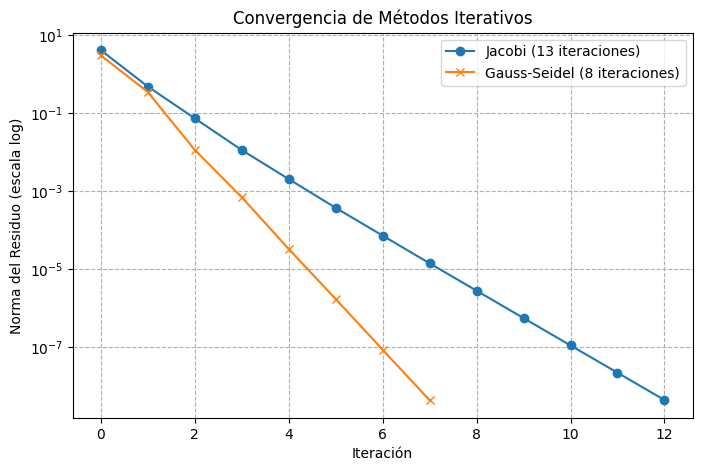

In [ ]:
print(f"Iteraciones Jacobi:       {iter_jacobi}")
print(f"Iteraciones Gauss-Seidel: {iter_gs}")

# Graficamos la convergencia (Norma del residuo vs Iteración)
plt.figure(figsize=(8, 5))
plt.plot(res_jacobi, label=f'Jacobi ({iter_jacobi} iteraciones)', marker='o')
plt.plot(res_gs, label=f'Gauss-Seidel ({iter_gs} iteraciones)', marker='x')
plt.yscale('log') # Escala logarítmica para apreciar la convergencia lineal
plt.xlabel('Iteración')
plt.ylabel('Norma del Residuo (escala log)')
plt.title('Convergencia de Métodos Iterativos')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Observaciones

Como se observa en la gráfica, Gauss-Seidel converge más rápido que Jacobi para este problema. La convergencia de estos métodos, cuando ocurre, es lineal (por eso se ve como una línea recta en escala logarítmica).

**Teorema: Estricta Dominancia Diagonal (SDD)**

Si la matriz $A$ es Estrictamente Diagonal Dominante, es decir, si para toda fila $i$:

$$ |a_{ii}| > \sum_{j\neq i} |a_{ij}| $$

Entonces, tanto Jacobi como Gauss-Seidel convergen a la solución única para cualquier suposición inicial $\mathbf{x}^{(0)}$.

## 5. Ejercicios

### Ejercicio 1: Verificación de SDD

Escribe una función `es_SDD(A)` que reciba una matriz `A` y devuelva `True` si es Estrictamente Diagonal Dominante (SDD) y `False` en caso contrario. Usa operaciones de NumPy (evita bucles `for` si es posible).

**Pista:** Puedes usar `np.diag(A)`, `np.abs(A)`, `np.sum(A, axis=1)` y `np.all()`.

In [ ]:
A1 = np.array([[5, 1, 1],
               [1, 3, 1],
               [0, 1, 4]])

A2 = np.array([[2, 3, 1],
               [4, 1, 5],
               [1, 2, 1]])

def es_SDD(A):
    # 1. Obtener el valor absoluto de los elementos de la diagonal
    diag_abs = np.abs(np.diag(A))

    # 2. Calcular la suma de los valores absolutos de cada fila completa
    # axis=1 indica que sumamos horizontalmente
    row_sum_abs = np.sum(np.abs(A), axis=1)

    # 3. Obtener la suma de los elementos fuera de la diagonal
    # Restamos la diagonal a la suma total de la fila
    off_diag_sum = row_sum_abs - diag_abs

    # 4. Verificar si la diagonal es mayor que la suma del resto para TODAS las filas
    return np.all(diag_abs > off_diag_sum)

print(f"A1 es SDD: {es_SDD(A1)}") # Debería ser True
print(f"A2 es SDD: {es_SDD(A2)}") # Debería ser False

A1 es SDD: True
A2 es SDD: False


### Ejercicio 2: Comparación en un sistema de aplicación (Ecuación de Laplace)

Vamos a comparar el rendimiento en una matriz que surge de la discretización de la ecuación de Laplace (común en simulación física y procesamiento de imágenes). Esta matriz es naturalmente SDD (o al menos diagonal dominante).

**Instrucciones:**
1. Ejecuta la celda para generar el sistema $A\mathbf{x}=\mathbf{b}$ de tamaño $N=100$.
2. Resuelve el sistema usando `jacobi_vectorizado` y `gauss_seidel` con una tolerancia de `1e-8`.
3. Compara el número de iteraciones y grafica la convergencia.
4. **Pregunta:** ¿Cuál es el ratio de iteraciones (Jacobi / Gauss-Seidel)?

Resolviendo sistema de tamaño N=100 (esto puede tardar unos segundos)...
------------------------------
Iteraciones Jacobi: 38572
Iteraciones Gauss-Seidel: 19287
Ratio (Jacobi / GS): 2.00
------------------------------


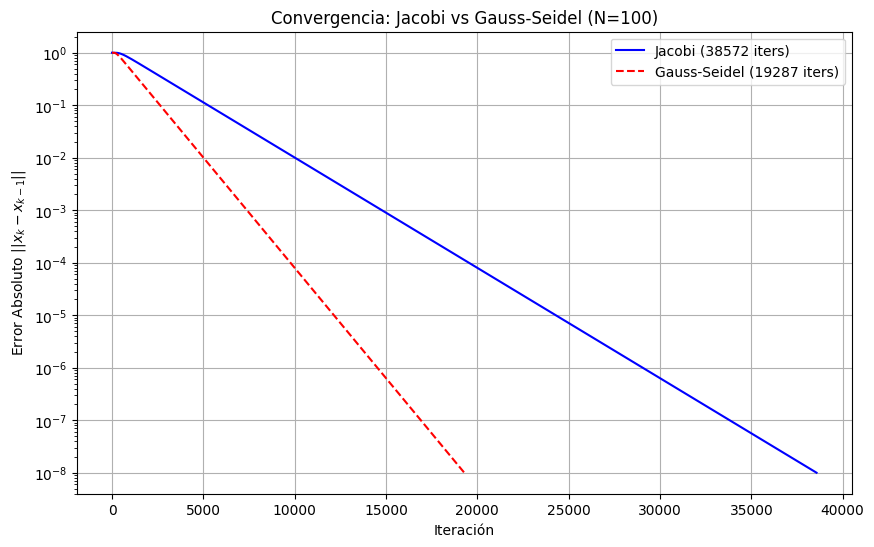

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definición del Sistema y Métodos ---

# Generador de la matriz de Laplace 1D
def generar_sistema_laplace(N):
    # Matriz A: diagonal principal es 2, diagonales superior e inferior son -1
    A = np.diag(2.0 * np.ones(N)) + \
        np.diag(-1.0 * np.ones(N-1), k=1) + \
        np.diag(-1.0 * np.ones(N-1), k=-1)
    b = np.ones(N)
    x0 = np.zeros(N)
    return A, b, x0

N = 100
A_laplace, b_laplace, x0_laplace = generar_sistema_laplace(N)

print(f"Resolviendo sistema de tamaño N={N} (esto puede tardar unos segundos)...")

# Aumentamos max_iter para asegurar convergencia con N=100
# (Jacobi requiere aprox 37,000 iters para este caso)
limit_iter = 40000

sol_jac, its_jac, errs_jac = jacobi_vectorizado(A_laplace, b_laplace, x0_laplace, tol=1e-8, max_iter=limit_iter)
sol_gs, its_gs, errs_gs = gauss_seidel(A_laplace, b_laplace, x0_laplace, tol=1e-8, max_iter=limit_iter)

# --- 3. Resultados y Gráfica ---

print("-" * 30)
print(f"Iteraciones Jacobi: {its_jac}")
print(f"Iteraciones Gauss-Seidel: {its_gs}")

ratio = its_jac / its_gs
print(f"Ratio (Jacobi / GS): {ratio:.2f}")
print("-" * 30)

plt.figure(figsize=(10, 6))
plt.plot(errs_jac, label=f'Jacobi ({its_jac} iters)', color='blue')
plt.plot(errs_gs, label=f'Gauss-Seidel ({its_gs} iters)', color='red', linestyle='--')
plt.yscale('log') # Escala logarítmica para ver la convergencia lineal
plt.title(f'Convergencia: Jacobi vs Gauss-Seidel (N={N})')
plt.xlabel('Iteración')
plt.ylabel('Error Absoluto $||x_k - x_{k-1}||$')
plt.legend()
plt.grid()
plt.show()

### Ejercicio 3: El impacto del orden de las ecuaciones

La convergencia de los métodos iterativos depende de las propiedades de la matriz de iteración. Cambiar el orden de las ecuaciones (permutar filas) puede cambiar estas propiedades.

Considera los siguientes dos sistemas, que son matemáticamente equivalentes:

**Sistema 1 (no SDD):**
$$ A_1 = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}, \quad \mathbf{b}_1 = \begin{pmatrix} 3 \\ 7 \end{pmatrix} $$

**Sistema 2 (permutado, no SDD):**
$$ A_2 = \begin{pmatrix} 3 & 4 \\ 1 & 2 \end{pmatrix}, \quad \mathbf{b}_2 = \begin{pmatrix} 7 \\ 3 \end{pmatrix} $$

(La solución exacta para ambos es (1, 1)).

**Instrucciones:**
1. Intenta resolver el Sistema 1 usando Jacobi y Gauss-Seidel (`max_iter=50`). ¿Convergen?
2. Intenta resolver el Sistema 2 usando Jacobi y Gauss-Seidel. ¿Convergen?
3. **Pregunta:** ¿Por qué el comportamiento de convergencia cambió si los sistemas son equivalentes? Reflexiona sobre cómo el algoritmo utiliza los elementos diagonales ($a_{ii}$).

--- Sistema 1 ---
Advertencia: Jacobi no converge después de 50 iteraciones.
Advertencia: Gauss-Seidel no converge después de 50 iteraciones.
Jacobi: 50 iters. Sol final: [-25250.1683 -25250.1683] (Error: 1.77e+05)
Gauss-Seidel: 50 iters. Sol final: [ 8.5016e+08 -6.3762e+08] (Error: 4.25e+08)

--- Sistema 2 ---
Advertencia: Jacobi no converge después de 50 iteraciones.
Jacobi: 50 iters. Sol final: [1. 1.] (Error: 2.77e-04)
Gauss-Seidel: 48 iters. Sol final: [1. 1.] (Error: 7.06e-09)


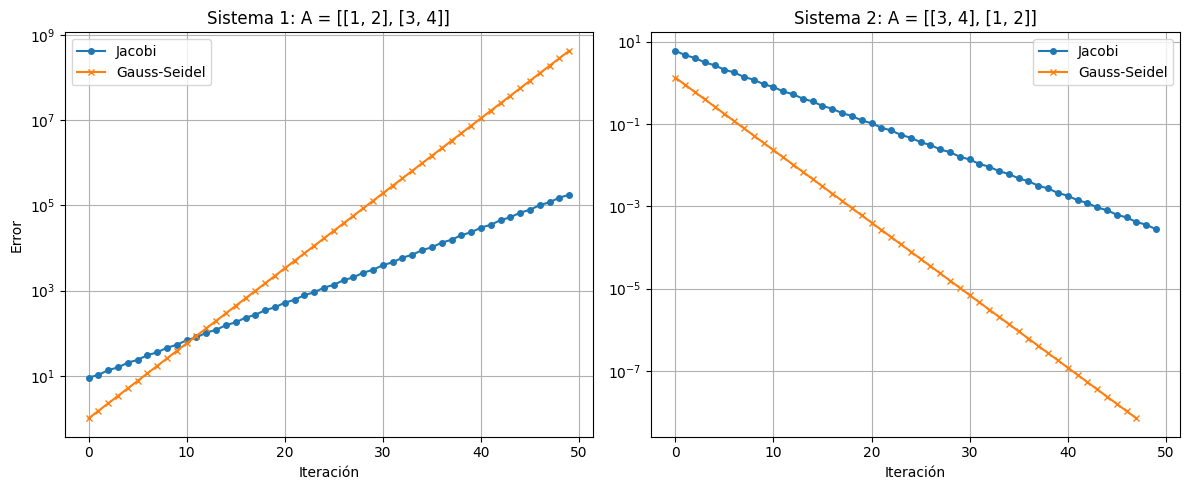

In [ ]:
A1 = np.array([[1.0, 2.0], [3.0, 4.0]])
b1 = np.array([3.0, 7.0])
A2 = np.array([[3.0, 4.0], [1.0, 2.0]])
b2 = np.array([7.0, 3.0])
x0 = np.zeros(2)

x0 = np.zeros(2)
tol = 1e-8
max_iter = 50

# --- Ejecución ---

print("--- Sistema 1 ---")
sol_j1, its_j1, err_j1 = jacobi_vectorizado(A1, b1, x0, tol, max_iter)
sol_gs1, its_gs1, err_gs1 = gauss_seidel(A1, b1, x0, tol, max_iter)
print(f"Jacobi: {its_j1} iters. Sol final: {sol_j1} (Error: {err_j1[-1]:.2e})")
print(f"Gauss-Seidel: {its_gs1} iters. Sol final: {sol_gs1} (Error: {err_gs1[-1]:.2e})")

print("\n--- Sistema 2 ---")
sol_j2, its_j2, err_j2 = jacobi_vectorizado(A2, b2, x0, tol, max_iter)
sol_gs2, its_gs2, err_gs2 = gauss_seidel(A2, b2, x0, tol, max_iter)
print(f"Jacobi: {its_j2} iters. Sol final: {sol_j2} (Error: {err_j2[-1]:.2e})")
print(f"Gauss-Seidel: {its_gs2} iters. Sol final: {sol_gs2} (Error: {err_gs2[-1]:.2e})")

# --- Gráfica Comparativa ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sistema 1
ax1.plot(err_j1, label='Jacobi', marker='o', markersize=4)
ax1.plot(err_gs1, label='Gauss-Seidel', marker='x', markersize=4)
ax1.set_yscale('log')
ax1.set_title('Sistema 1: A = [[1, 2], [3, 4]]')
ax1.set_xlabel('Iteración')
ax1.set_ylabel('Error')
ax1.legend()
ax1.grid()

# Sistema 2
ax2.plot(err_j2, label='Jacobi', marker='o', markersize=4)
ax2.plot(err_gs2, label='Gauss-Seidel', marker='x', markersize=4)
ax2.set_yscale('log')
ax2.set_title('Sistema 2: A = [[3, 4], [1, 2]]')
ax2.set_xlabel('Iteración')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

### Pregunta reflexiva

**¿Por qué el comportamiento de convergencia cambió si los sistemas son equivalentes? Reflexiona sobre cómo el algoritmo utiliza los elementos diagonales ($a_{ii}$)**

Mi respuesta: Primero que nada, hay que observar que en el sistema 1, ambos métodos divergen y el error crece rapidamente, mientras que en el sistema 2, ambos métodos convergen con Gauss-Seidel convergiendo mucho mas rápido que Jacobi

Este comportamiento se debe a que los métodos iterativos como Jacobi y Gauss-Seidel dividen por los elementos de la diagonal ($a_{ii}$) en cada paso para despejar $x_i$.

- En el Sistema 1, estamos dividiendo por 1 y 4. Los elementos fuera de la diagonal (2 y 3) son "pesados" en comparación, lo que hace que el error se amplifique en cada paso

- En el Sistema 2 (permutado), dividimos por 3 y 2. Aunque no es perfectamente dominante ($3 \not> 4$), los elementos diagonales son lo suficientemente grandes para mantener el error bajo control (el radio espectral de la matriz de iteración se vuelve menor a 1), permitiendo la convergencia.

Esto demuestra que el pivoteo (reordenar filas) es crucial no solo en eliminación gaussiana, sino también para la convergencia de métodos iterativos.

## 4. Análisis de rendimiento y sistemas grandes (benchmarking)

Hasta ahora, hemos comparado Jacobi y Gauss-Seidel basándonos en el **número de iteraciones**. Sin embargo, un factor importante es el **tiempo de ejecución** (wall-clock time).

Vamos a realizar un benchmark para comparar cómo se comportan estos algoritmos a medida que el tamaño del sistema ($N$) aumenta.

**Consideraciones:**

1.  **Costo por iteración:** Ambos métodos tienen un costo de $O(N^2)$ por iteración para matrices densas.
2.  **Implementación:** Estamos comparando nuestra implementación **vectorizada** de Jacobi (eficiente en NumPy) con la implementación **secuencial** de Gauss-Seidel (limitada por el bucle `for` de Python).
3.  **Convergencia:** Para garantizar que los métodos converjan, generaremos matrices aleatorias que sean Estrictamente Diagonal Dominantes (SDD).

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Función auxiliar para generar matrices SDD aleatorias
def generar_matriz_SDD(N):
    # Genera una matriz aleatoria entre -1 y 1
    A = np.random.rand(N, N) * 2 - 1
    # Asegura la dominancia diagonal:
    # 1. Eliminamos la diagonal original temporalmente para calcular la suma fuera de la diagonal
    np.fill_diagonal(A, 0)
    # 2. Calculamos la suma de los valores absolutos de cada fila (sin la diagonal)
    sum_abs_off_diag = np.sum(np.abs(A), axis=1)
    # 3. Hacemos la diagonal estrictamente mayor que esa suma (añadiendo un margen)
    # Esto garantiza que |a_ii| > sum_{j!=i} |a_ij|
    np.fill_diagonal(A, sum_abs_off_diag + np.random.rand(N) * 0.1 + 0.01)
    return A

# Función para ejecutar el benchmark
def run_benchmark(sizes, trials=3, tol=1e-6):
    results = []
    print("Iniciando benchmark...")

    for N in sizes:
#        print(f"\nTamaño N={N}...", end="")
        time_jacobi = []
        iter_jacobi = []
        time_gs = []
        iter_gs = []

        # Realizamos 'trials' intentos y promediamos
        for t in range(trials):
            # 1. Generar el sistema
            A = generar_matriz_SDD(N)
            b = np.random.rand(N)
            x0 = np.zeros(N)

            # 2. Benchmark Jacobi
            # Usamos time.perf_counter() para medir el tiempo
            start_time = time.perf_counter()
            # Usamos un max_iter razonable
            _, iters_j, _ = jacobi_vectorizado(A, b, x0, tol=tol, max_iter=500)
            end_time = time.perf_counter()
            time_jacobi.append(end_time - start_time)
            iter_jacobi.append(iters_j)

            # 3. Benchmark Gauss-Seidel
            start_time = time.perf_counter()
            _, iters_gs, _ = gauss_seidel(A, b, x0, tol=tol, max_iter=500)
            end_time = time.perf_counter()
            time_gs.append(end_time - start_time)
            iter_gs.append(iters_gs)

#            print(f".", end="")

        # Almacenar los promedios
        results.append({
            'N': N,
            'Avg Time Jacobi (s)': np.mean(time_jacobi),
            'Avg Iters Jacobi': np.mean(iter_jacobi),
            'Avg Time GS (s)': np.mean(time_gs),
            'Avg Iters GS': np.mean(iter_gs),
        })

    print("\nBenchmark finalizado.")
    return pd.DataFrame(results)

In [ ]:
# Definimos los tamaños a probar.
# Limitamos el tamaño máximo porque la implementación de GS en Python puro es lenta.
# Si N es muy grande, el tiempo de ejecución se dispara.
sizes_to_test = np.arange(10, 2001, 10)
# Ejecutamos el benchmark.
# ADVERTENCIA: Esta celda puede tardar varios minutos.
benchmark_results = run_benchmark(sizes_to_test, trials=3, tol=1e-5)

Iniciando benchmark...

Benchmark finalizado.


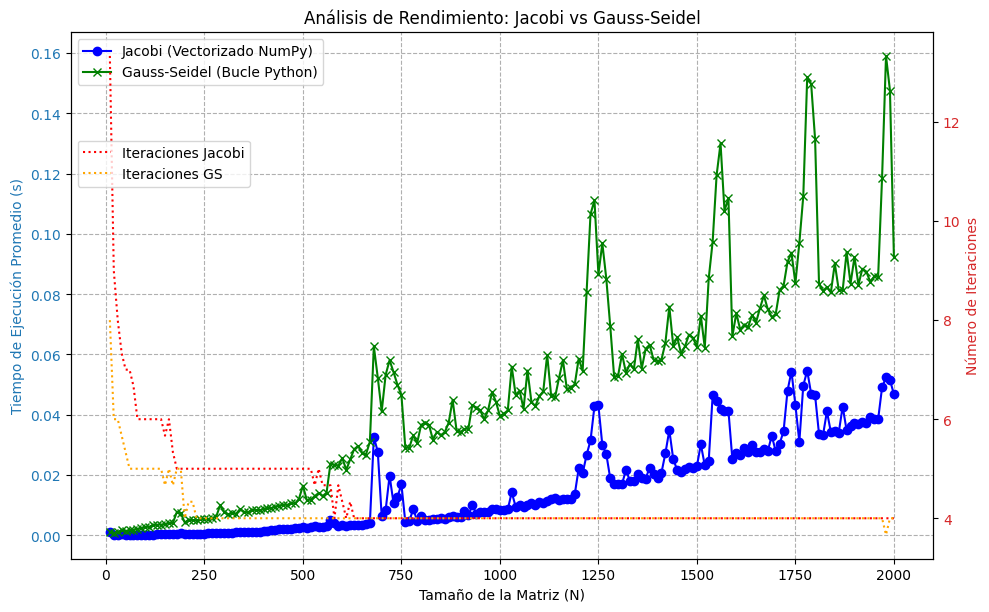

In [ ]:
# Graficamos los resultados usando una gráfica con dos ejes Y
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y izquierdo: Tiempo de ejecución
color = 'tab:blue'
ax1.set_xlabel('Tamaño de la Matriz (N)')
ax1.set_ylabel('Tiempo de Ejecución Promedio (s)', color=color)
ax1.plot(benchmark_results['N'], benchmark_results['Avg Time Jacobi (s)'], label='Jacobi (Vectorizado NumPy)', color='blue', marker='o')
ax1.plot(benchmark_results['N'], benchmark_results['Avg Time GS (s)'], label='Gauss-Seidel (Bucle Python)', color='green', marker='x')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--')

# Eje Y derecho: Número de Iteraciones
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Número de Iteraciones', color=color)
# Usamos líneas punteadas para las iteraciones
ax2.plot(benchmark_results['N'], benchmark_results['Avg Iters Jacobi'], label='Iteraciones Jacobi', color='red', linestyle=':')
ax2.plot(benchmark_results['N'], benchmark_results['Avg Iters GS'], label='Iteraciones GS', color='orange', linestyle=':')
ax2.tick_params(axis='y', labelcolor=color)
# Ajustamos la leyenda del segundo eje
ax2.legend(loc='center left', bbox_to_anchor=(0.0, 0.75))

fig.tight_layout()
plt.title('Análisis de Rendimiento: Jacobi vs Gauss-Seidel')
plt.show()

### Análisis de los resultados del benchmark

Observando la gráfica, podemos notar la **paradoja del rendimiento en Python**:

1.  **Iteraciones (líneas punteadas):** Gauss-Seidel utiliza consistentemente menos iteraciones que Jacobi. Matemáticamente, es superior en este aspecto.
2.  **Tiempo de ejecución (líneas sólidas):** Jacobi es significativamente más rápido que Gauss-Seidel.

Lo anterior se debe a la **implementación**:
*   Nuestra implementación de Jacobi está completamente **vectorizada**. NumPy ejecuta estas operaciones usando bibliotecas C/Fortran altamente optimizadas (como BLAS), que son muy eficientes en CPUs modernas.
*   Nuestra implementación de Gauss-Seidel requiere un bucle `for` explícito en Python debido a su naturaleza secuencial. La sobrecarga del intérprete de Python al ejecutar este bucle es tan grande que anula la ventaja de tener menos iteraciones.

Para matrices densas en Python/NumPy estándar, la eficiencia de la vectorización de Jacobi supera la ventaja matemática de convergencia de Gauss-Seidel.

## 7. Optimización y paralelización con Numba
¿Podemos hacer que Gauss-Seidel sea competitivo? ¿Podemos acelerar Jacobi aún más usando paralelismo explícito?

Para optimizar código Python que involucra bucles intensivos, usamos Numba. Numba es un compilador Just-In-Time (JIT) que traduce funciones de Python a código máquina rápido.

Objetivos:
1. Optimizar Gauss-Seidel: Usar Numba (@njit) para compilar la implementación secuencial y eliminar el overhead del bucle for de Python.

2. Paralelizar Jacobi: Usar Numba (@njit(parallel=True) y prange) para distribuir el trabajo de Jacobi en todos los núcleos de CPU disponibles.

Perspectiva CS: Numba y el GIL Python estándar tiene limitaciones (como el Global Interpreter Lock - GIL) que dificultan el paralelismo real en tareas intensivas de CPU. Numba puede compilar el código y liberar el GIL, permitiendo que el algoritmo utilice eficientemente todos los núcleos de la CPU disponibles.

In [ ]:
# Importamos Numba
from numba import njit, prange

# 1. Gauss-Seidel optimizado con Numba (@njit)
# Compilar la función a código máquina

@njit
def gauss_seidel_numba(A, b, x0, tol=1e-6, max_iter=1000):
    N = A.shape[0]
    x = x0.copy()

    for k in range(max_iter):
        # Nota: Para máxima velocidad en Numba, cambiamos el criterio de paro.
        # Calcular el residuo ||b-Ax|| requiere una operación matriz-vector completa.
        # Usaremos la norma infinita del cambio en x ||x_new - x_old||, que es más rápida
        # de calcular dentro del bucle.
        max_change = 0.0

        for i in range(N):
            # Implementación explícita de las sumas (Numba optimiza esto muy bien)
            sum_val = 0.0
            for j in range(N):
                if i != j:
                    # Usamos el valor más reciente de x[j]
                    sum_val += A[i, j] * x[j]

            x_new_i = (b[i] - sum_val) / A[i, i]

            # Actualizar el cambio máximo
            change = abs(x_new_i - x[i])
            if change > max_change:
                max_change = change

            x[i] = x_new_i # Actualización in-place

        # Criterio de paro
        if max_change < tol:
            return x, k + 1

    return x, max_iter

# 2. Jacobi paralelo con Numba (@njit(parallel=True))
# Usamos prange para el bucle externo para indicar paralelismo.

@njit(parallel=True)
def jacobi_parallel_numba(A, b, x0, tol=1e-6, max_iter=1000):
    N = A.shape[0]
    x_old = x0.copy()
    # Usamos np.empty_like para inicializar sin llenar de ceros
    x_new = np.empty_like(x0)
    D = np.diag(A)

    for k in range(max_iter):

        # Bucle paralelo: cada hilo de CPU calcula una parte de x_new
        for i in prange(N):
            sum_val = 0.0
            # Bucle interno (secuencial por hilo)
            for j in range(N):
                if i != j:
                    sum_val += A[i, j] * x_old[j]
            x_new[i] = (b[i] - sum_val) / D[i]

        # Criterio de paro (calculado secuencialmente después del bloque paralelo)
        max_change = 0.0
        # Nota: Este chequeo también se podría paralelizar con operaciones de reducción.
        for i in range(N):
            change = abs(x_new[i] - x_old[i])
            if change > max_change:
                max_change = change

        if max_change < tol:
            return x_new, k + 1

        # Actualización del buffer
        for i in prange(N):
            x_old[i] = x_new[i]

    return x_new, max_iter

In [ ]:
N_large = 15000
tol = 1e-5
MAX_ITER = 500
print(f"Comparando métodos para N={N_large}...")

# Generar el sistema
A_large = generar_matriz_SDD(N_large)
b_large = np.random.rand(N_large)
x0_large = np.zeros(N_large)

# Función auxiliar para ejecutar y medir, manejando el tiempo de compilación JIT (warm-up)
def time_solver(solver_func, name, A, b, x0, tol, max_iter):
    start_time = time.perf_counter()
    result = solver_func(A, b, x0, tol=tol, max_iter=max_iter)
    time_taken = time.perf_counter() - start_time

    # Determinamos las iteraciones basadas en la salida de la función
    # (Las funciones originales devuelven 3 valores, las de Numba devuelven 2)
    if len(result) >= 2:
        iters = result[1]
    else:
        iters = "N/A"

    print(f"{name:<30}: {time_taken:.4f} s | Iters: {iters}")

# --- Ejecución del benchmark ---

time_solver(jacobi_vectorizado, "Jacobi (NumPy Vectorizado)", A_large, b_large, x0_large, tol, MAX_ITER)
# ADVERTENCIA: Esto podría ser lento!!!
time_solver(gauss_seidel, "Gauss-Seidel (Python Seq)", A_large, b_large, x0_large, tol, MAX_ITER)
time_solver(gauss_seidel_numba, "Gauss-Seidel (Numba Opt Seq)", A_large, b_large, x0_large, tol, MAX_ITER)
time_solver(jacobi_parallel_numba, "Jacobi (Numba Paralelo)", A_large, b_large, x0_large, tol, MAX_ITER)

Comparando métodos para N=15000...
Jacobi (NumPy Vectorizado)    : 2.2475 s | Iters: 3
Gauss-Seidel (Python Seq)     : 3.7037 s | Iters: 3
Gauss-Seidel (Numba Opt Seq)  : 2.2719 s | Iters: 2
Jacobi (Numba Paralelo)       : 2.4089 s | Iters: 2


# **Práctica de Análisis Numérico: Estudio comparativo de métodos iterativos por Gradiente** 📌

## **Introducción**

El objetivo de esta práctica es implementar y comparar el rendimiento computacional
de tres métodos iterativos para la solución de sistemas de ecuaciones lineales de la forma
$Ax = b$, donde $A$ es una matriz simétrica definida positiva (SDP).
La comparación busca evaluar empíricamente la velocidad de convergencia y la eficiencia de los siguientes algoritmos:
1. Descenso por gradiente (GD) con tasa de aprendizaje fija.
2. Método de máximo descenso (SD) con tasa de aprendizaje óptima.
3. Método de gradiente conjugado (CG).

## **1. Metodología de generación de datos**

Para asegurar la reproducibilidad y la validez de la comparación, todos los métodos seprobarán sobre el mismo conjunto de problemas generados sintéticamente. Un problema
individual ($A, b, x_{\text{exacta}}$) se construirá de la siguiente manera:

1. Definir la dimensión $n$.
2. Generar la matriz $A$ (SDP):
- Crear una matriz $L$, triangular inferior de $n$ × $n$.
- Llenar la diagonal de $L$ con el valor 1.
- Llenar las entradas no diagonales por debajo de la diagonal principal ($L_{𝑖𝑗}$ con $i > j$) con valores aleatorios muestreados de una distribución uniforme $U(0, 1)$.
- Construir la matriz $A$ como $A = L^TL$. Esta construcción garantiza que A sea simétrica y definida positiva.

3. Generar la solución $x_{\text{exacta}}$.
- Crear un vector $x_{\text{exacta}}$ de dimensión $n \times 1$ con componentes aleatorias (por ejemplo, $U(0,1)$), asegurando que no sea el vector nulo.

4. Calcular el vector $b$:
- Calcular $b=A$ $x_{\text{exacta}}$

Todos los algoritmos partirán de una estimación inicial \$ x_{0} = \vec{0} \$ (el vector de ceros).


In [ ]:
def generar_problema(n):

    # Generar L y A
    L = np.tril(np.random.uniform(0, 1, (n, n)))
    np.fill_diagonal(L, 1.0)
    A = L.T @ L

    # --- CORRECCIÓN AQUÍ: Asegurar dimensión (n, 1) ---
    # Antes: size=n (esto daba dimensión (n,))
    # Ahora: size=(n, 1) (esto da dimensión n x 1, vector columna)
    x_exact = np.random.uniform(0, 1, (n, 1))

    b = A @ x_exact

    # --- Definición del punto de partida x0 ---
    x0 = np.zeros((n, 1))

    # --- CORRECCIÓN AQUÍ: Nombre de la variable ---
    # Antes decía: return A, b, x_exacta, x0  <-- Error, x_exacta no existía
    return A, b, x_exact, x0

## **2. Algoritmos a implementar**

Se deben implementar los siguientes tres algoritmos. Para todos ellos, se define el residual en la $k$-ésima iteración como $ r_k = b - A x_k. $

### **2.1. Descenso por gradiente (GD)**

La fórmula de iteración es:
\begin{align}
 x_{k+1} = x_k + \alpha r_k
\end{align}

Se utilizará una tasa de aprendizaje fija $α = 10^{-3}$

In [ ]:
def gradient_descent(A, b, x0, alpha=1e-3, tol=1e-6, max_iter=50000):

    x = x0.copy()

    # residuo inicial
    r = b - A @ x

    # Norma de b para el error relativo
    b_norm = np.linalg.norm(b)

    # Lista para guardar el historial de convergencia (para las gráficas)
    errores = []

    for k in range(max_iter):
        # Calcular la norma del residual actual
        r_norm = np.linalg.norm(r)
        errores.append(r_norm)

        # Calcular error relativo
        rel = r_norm / b_norm

        # Criterio de parada: Convergencia
        if rel < tol:
            return x, k, errores

        # Criterio de seguridad: Divergencia (si explota)
        if rel > 1e6:
            print("Advertencia: GD divergió.")
            return x, k, errores

        # --- Paso de iteración ---
        x = x + alpha * r

        # Recalcular residual
        r = b - A @ x

    return x, max_iter, errores

###2.2. Método de máximo descenso (SD)

La fórmula de iteración es idéntica a $GD$, pero la tasa de aprendizaje $a_k$ se recalcula en cada paso para ser óptima:

\begin{align}
x_{k+1} = x_k + \alpha_k r_k
\end{align}

\begin{align}
\alpha_k = \frac{r_k^T r_k}{r_k^T A r_k}
\end{align}

In [ ]:
def steepest_descent(A, b, x0, tol=1e-6, max_iter=50000):
    """
    Método de Máximo Descenso (Steepest Descent) corregido.
    """
    x = x0.copy()
    r = b - A @ x
    b_norm = np.linalg.norm(b)
    errores = []

    for k in range(max_iter):
        r_norm = np.linalg.norm(r)
        errores.append(r_norm)

        # Evitar división por cero
        if b_norm > 0:
            rel = r_norm / b_norm
        else:
            rel = r_norm

        if rel < tol:
            return x, k, errores
        if rel > 1e6:
            return x, k, errores

        Ar = A @ r

        # Calculamos productos punto (resultan en matrices 1x1)
        numerador = r.T @ r
        denominador = r.T @ Ar

        # Extraer el valor escalar (.item()) para evitar errores de dimensión
        if denominador.item() == 0:
            break

        # --- CORRECCIÓN AQUÍ: Usar 'numerador' (español) ---
        alpha = numerador.item() / denominador.item()

        x = x + alpha * r
        r = b - A @ x

    return x, max_iter, errores


### **2.3. Método de gradiente conjugado (CG)**

Se debe implementar el algoritmo estándar de gradiente conjugado.

In [ ]:
def conjugate_gradient(A, b, x0, tol=1e-6, max_iter=50000):
    """
    Método de Gradiente Conjugado (CG) corregido.
    """
    x = x0.copy()
    r = b - A @ x
    p = r.copy()
    b_norm = np.linalg.norm(b)
    errores = []

    for k in range(max_iter):
        r_norm = np.linalg.norm(r)
        errores.append(r_norm)

        rel = r_norm / b_norm if b_norm > 0 else r_norm

        if rel < tol:
            return x, k, errores
        if rel > 1e6:
            return x, k, errores

        Ap = A @ p

        # Productos punto (1x1)
        r_dot_r = r.T @ r
        p_dot_Ap = p.T @ Ap

        # Calcular alpha (usando .item() para seguridad)
        if p_dot_Ap.item() == 0:
            break
        alpha = r_dot_r.item() / p_dot_Ap.item()

        x = x + alpha * p
        r_new = r - alpha * Ap

        # Calcular beta
        r_new_dot_r_new = r_new.T @ r_new

        if r_dot_r.item() == 0:
            break
        beta = r_new_dot_r_new.item() / r_dot_r.item()

        p = r_new + beta * p
        r = r_new

    return x, max_iter, errores

### **2.4. Criterios de paro**

Todos los algoritmos finalizarán cuando se cumpla la primera de las siguientes tres condiciones:

1. Convergencia (Error Residual Relativo): El error residual relativo es inferior a la tolerancia $TOL = 10^{-6}$.


\begin{align}
\frac{\lVert r_k \rVert_2}{\lVert b \rVert_2} < 10^{-6}
\end{align}

(Se asume $ b \ne 0$, lo cual está garantizado por la construcción del problema).



2. Divergencia: El error residual relativo supera $10^{6}$.

\begin{align}
\frac{\lVert r_k \rVert_2}{\lVert b \rVert_2} < 10^{-6}
\end{align}


3. Iteraciones Máximas: El número de iteraciones $k$ alcanza  $MAX$_$ITER = 50, 000$.

## **3. Diseño experimental y visualización**

### **3.1. Experimento de escalabilidad**

El objetivo es medir cómo varía el rendimiento de cada algoritmo a medida que aumenta la dimensión del problema.

- Dimensiones $(n)$: Se probará un conjunto de tamaños $n =$ 2, 3, 4, ..., 100.
- Réplicas $(M)$: Para cada $n$, se deben generar $M$ = 30 problemas aleatorios distintos.
- Métricas: Se debe registrar el tiempo de cómputo promedio y el número de iteraciones promedio para cada algoritmo en cada $n$. Si un método no converge (por
divergencia o $MAX$_$ITER$), se debe manejar adecuadamente en el promedio.

### 3.2. **Visualización de resultados**

Los resultados deberán visualizarse en una única gráfica que consolide todos los resultados, similar al ejemplo visto en clases anteriores. La gráfica debe tener las siguientes características:

- Un eje X compartido para el tamaño de la matriz $(n)$.
-  Un eje Y izquierdo para el tiempo de ejecución promedio en segundos.
- Un eje Y derecho (usando ‘twinx()‘) para el número de iteraciones promedio.

- Las líneas de tiempo (eje izquierdo) deben ser sólidas y con marcadores (ej. ’o’, ’x’, ’s’) para cada uno de los tres métodos $(GD, SD, CG)$.

Iniciando experimento (n=2 a 100, M=30)...
Procesando n=2...
Procesando n=3...
Procesando n=4...
Procesando n=5...
Procesando n=6...
Procesando n=7...
Procesando n=8...
Procesando n=9...
Procesando n=10...
  Procesado n=10...
Procesando n=11...
Procesando n=12...
Procesando n=13...
Procesando n=14...
Procesando n=15...
Procesando n=16...
Procesando n=17...
Procesando n=18...
Procesando n=19...
Procesando n=20...
  Procesado n=20...
Procesando n=21...
Procesando n=22...
Procesando n=23...
Procesando n=24...
Procesando n=25...
Procesando n=26...
Procesando n=27...
Procesando n=28...
Procesando n=29...
Procesando n=30...
  Procesado n=30...
Procesando n=31...
Procesando n=32...
Procesando n=33...
Procesando n=34...
Procesando n=35...
Procesando n=36...
Procesando n=37...
Procesando n=38...
Procesando n=39...
Procesando n=40...
  Procesado n=40...
Procesando n=41...
Procesando n=42...
Procesando n=43...
Procesando n=44...
Procesando n=45...
Procesando n=46...
Procesando n=47...
Procesando 

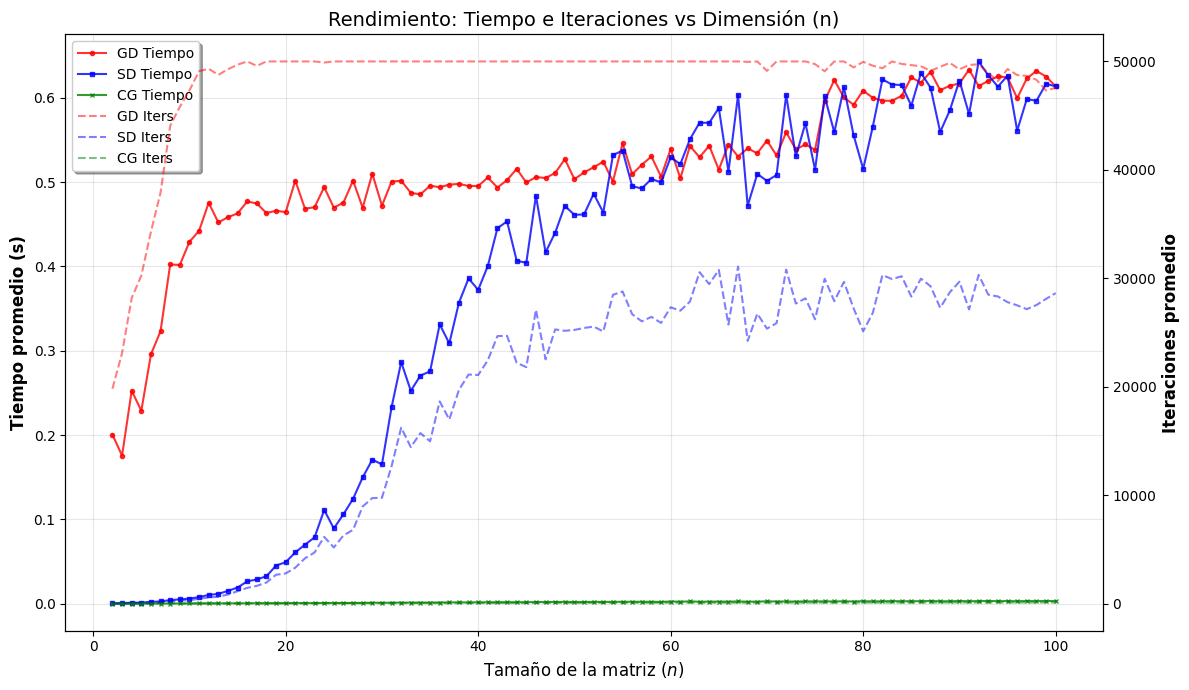

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- Configuración ---
n_dim = range(2, 101)
M = 30  # réplicas
tol = 1e-6
max_iter = 50000

# Estructuras para guardar promedios
avg_iters = {'GD': [], 'SD': [], 'CG': []}
avg_times = {'GD': [], 'SD': [], 'CG': []}

print(f"Iniciando experimento (n=2 a 100, M={M})...")

for n in n_dim:
    print(f"Procesando n={n}...")
    # Listas temporales para las réplicas
    it_replicas = {'GD': [], 'SD': [], 'CG': []}
    ti_replicas = {'GD': [], 'SD': [], 'CG': []}

    for _ in range(M):
        # CORRECCIÓN: Recibimos los 4 valores (incluyendo x0 con dimensiones correctas)
        A, b, x_exact, x0 = generar_problema(n)

        # ==========================
        # 1. GD - Descenso por Gradiente
        # ==========================
        t0 = time.perf_counter()
        # Usamos nuestras funciones (que devuelven x, k, historial)
        _, k, _ = gradient_descent(A, b, x0, alpha=1e-3, tol=tol, max_iter=max_iter)
        ti_replicas['GD'].append(time.perf_counter() - t0)
        it_replicas['GD'].append(k)

        # ==========================
        # 2. SD - Máximo Descenso
        # ==========================
        t0 = time.perf_counter()
        _, k, _ = steepest_descent(A, b, x0, tol=tol, max_iter=max_iter)
        ti_replicas['SD'].append(time.perf_counter() - t0)
        it_replicas['SD'].append(k)

        # ==========================
        # 3. CG - Gradiente Conjugado
        # ==========================
        t0 = time.perf_counter()
        _, k, _ = conjugate_gradient(A, b, x0, tol=tol, max_iter=max_iter)
        ti_replicas['CG'].append(time.perf_counter() - t0)
        it_replicas['CG'].append(k)

    # Promediar réplicas y guardar
    for m in ['GD', 'SD', 'CG']:
        avg_times[m].append(np.mean(ti_replicas[m]))
        avg_iters[m].append(np.mean(it_replicas[m]))

    # Feedback visual ocasional
    if n % 10 == 0:
        print(f"  Procesado n={n}...")

# ====================================================
# GRÁFICA CONSOLIDADA (Doble Eje - twinx)
# Requisito del PDF: Eje izquierdo (Tiempo), Eje derecho (Iteraciones)
# ====================================================

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_xlabel('Tamaño de la matriz ($n$)', fontsize=12)
ax1.set_ylabel('Tiempo promedio (s)', fontsize=12, fontweight='bold')
ax1.set_title('Rendimiento: Tiempo e Iteraciones vs Dimensión (n)', fontsize=14)

# --- Eje Izquierdo: TIEMPO (Líneas sólidas con marcadores) ---
l1, = ax1.plot(n_dim, avg_times['GD'], 'r-o', label='GD Tiempo', markersize=3, alpha=0.8)
l2, = ax1.plot(n_dim, avg_times['SD'], 'b-s', label='SD Tiempo', markersize=3, alpha=0.8)
l3, = ax1.plot(n_dim, avg_times['CG'], 'g-x', label='CG Tiempo', markersize=3, alpha=0.8)

# --- Eje Derecho: ITERACIONES (Líneas discontinuas) ---
ax2 = ax1.twinx()
ax2.set_ylabel('Iteraciones promedio', fontsize=12, fontweight='bold')

l4, = ax2.plot(n_dim, avg_iters['GD'], 'r--', label='GD Iters', alpha=0.5)
l5, = ax2.plot(n_dim, avg_iters['SD'], 'b--', label='SD Iters', alpha=0.5)
l6, = ax2.plot(n_dim, avg_iters['CG'], 'g--', label='CG Iters', alpha=0.5)

# Leyenda combinada
lines = [l1, l2, l3, l4, l5, l6]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10, frameon=True, shadow=True)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()